# AAPL Model Development

This notebook develops and evaluates regression models for **next-trading-day adjusted closing-price prediction**.

It satisfies the CSM3601 Model Development requirements:

- at least three machine-learning models;
- chronological train/validation/test splitting;
- `Pipeline` implementation;
- time-series cross-validation;
- hyperparameter tuning;
- overfitting checks;
- comparison with a persistence baseline;
- MAE, MSE, RMSE, R-squared, and Directional Accuracy;
- feature-importance and residual interpretation.

**Evaluation protocol:** 2015-2022 data are used for training and time-series cross-validation, 2023 is used once for model selection, and the locked model is evaluated on the untouched 2024 test set.


## Workflow overview

This notebook follows the model-development workflow:

1. Load the prepared dataset from the EDA phase.
2. Keep the time order: Train = 2015-2022, Validation = 2023, Test = 2024.
3. Build model pipelines and tune hyperparameters with time-series cross-validation.
4. Select the best trained ML model using validation RMSE.
5. Evaluate the locked model on the untouched 2024 test set.
6. Save the final model, result tables, and figures.

Main point: Ridge Regression is selected because it is the best trained ML model on validation RMSE. The persistence baseline is kept as an honest simple benchmark.


In [1]:
from pathlib import Path
import json
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Fixed seed so random-based models are reproducible.
RANDOM_STATE = 42
MODEL_DIR = Path.cwd()
LOCAL_DATA_PATH = MODEL_DIR / "data" / "AAPL_Prepared_for_Modeling.csv"
PARENT_DATA_PATH = MODEL_DIR.parent / "AAPL_Prepared_for_Modeling.csv"
# Prefer the bundled data file; use parent folder only as a fallback.
DATA_PATH = LOCAL_DATA_PATH if LOCAL_DATA_PATH.exists() else PARENT_DATA_PATH
RESULTS_DIR = MODEL_DIR / "results"
FIGURES_DIR = MODEL_DIR / "figures"
MODELS_DIR = MODEL_DIR / "models"
# Create output folders for tables, figures, and saved model files.
for directory in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("Data path:", DATA_PATH.resolve())


Python: 3.14.3
pandas: 3.0.2
scikit-learn: 1.8.0
xgboost: 3.3.0
Data path: C:\Users\13136\Desktop\Group13_Lab3_AAPL_EDA\Submission_By_Phase\03_Model_Development_30pct\data\AAPL_Prepared_for_Modeling.csv


## 1. Load Data and Lock the Experimental Design


**Purpose of this section:** load the modeling CSV, define the input features and target, and make sure the train/validation/test periods are in the correct time order.

The target column is `Target_Close_t1`, which means the next trading day's adjusted close. We use features from day `t` to predict the close price on day `t+1`.


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

# Input variables created during data preparation and EDA.
feature_columns = [
    "Open", "High", "Low", "Close", "Volume",
    "MA7", "MA30", "Daily_Return", "Log_Return", "Volatility",
    "Volume_Change", "Log_Volume_Change", "Price_Range", "Open_Close_Change",
    "Close_Lag1", "Close_Lag5", "Return_Lag1", "Return_Lag5",
]
# Target: next trading day adjusted close price.
target_column = "Target_Close_t1"

required_columns = ["Date", "Split", target_column] + feature_columns
# Basic safety checks before model training.
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

assert df["Date"].is_monotonic_increasing
assert not df["Date"].duplicated().any()
assert not df[required_columns].isna().any().any()
assert target_column not in feature_columns
assert "Target_Return_t1" not in feature_columns

# The split labels were created earlier to keep chronological order.
train_df = df.loc[df["Split"] == "Train"].copy()
validation_df = df.loc[df["Split"] == "Validation"].copy()
test_df = df.loc[df["Split"] == "Test"].copy()

assert train_df["Date"].max() < validation_df["Date"].min()
assert validation_df["Date"].max() < test_df["Date"].min()

split_summary = pd.DataFrame(
    [
        {"Split": name, "Rows": len(part), "Start": part["Date"].min(), "End": part["Date"].max()}
        for name, part in [("Train", train_df), ("Validation", validation_df), ("Test", test_df)]
    ]
)
display(split_summary)
print("Features:", len(feature_columns))
print(feature_columns)


,Split,Rows,Start,End
0,Train,1985,2015-02-13,2022-12-30
1,Validation,250,2023-01-03,2023-12-29
2,Test,251,2024-01-02,2024-12-30


Features: 18
['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA30', 'Daily_Return', 'Log_Return', 'Volatility', 'Volume_Change', 'Log_Volume_Change', 'Price_Range', 'Open_Close_Change', 'Close_Lag1', 'Close_Lag5', 'Return_Lag1', 'Return_Lag5']


All features in row *t* are available after market close on day *t*. The target is the adjusted close on day *t+1*. The test set is not used for cross-validation, hyperparameter tuning, or model selection.


In [3]:
X_train = train_df[feature_columns]
y_train = train_df[target_column]
X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]
X_test = test_df[feature_columns]
y_test = test_df[target_column]

# Time-series CV: train on earlier dates and validate on later dates.
# The one-row gap helps reduce adjacent target overlap.
tscv = TimeSeriesSplit(n_splits=5, gap=1)
fold_rows = []
for fold, (fit_idx, cv_idx) in enumerate(tscv.split(X_train), start=1):
    fold_rows.append(
        {
            "Fold": fold,
            "Train_Rows": len(fit_idx),
            "Train_Start": train_df.iloc[fit_idx[0]]["Date"],
            "Train_End": train_df.iloc[fit_idx[-1]]["Date"],
            "CV_Rows": len(cv_idx),
            "CV_Start": train_df.iloc[cv_idx[0]]["Date"],
            "CV_End": train_df.iloc[cv_idx[-1]]["Date"],
            "Gap_Rows": cv_idx[0] - fit_idx[-1] - 1,
        }
    )

fold_summary = pd.DataFrame(fold_rows)
fold_summary.to_csv(RESULTS_DIR / "time_series_cv_folds.csv", index=False)
display(fold_summary)


,Fold,Train_Rows,Train_Start,Train_End,CV_Rows,CV_Start,CV_End,Gap_Rows
0,1,334,2015-02-13,2016-06-10,330,2016-06-14,2017-10-03,1
1,2,664,2015-02-13,2017-10-02,330,2017-10-04,2019-01-28,1
2,3,994,2015-02-13,2019-01-25,330,2019-01-29,2020-05-19,1
3,4,1324,2015-02-13,2020-05-18,330,2020-05-20,2021-09-09,1
4,5,1654,2015-02-13,2021-09-08,330,2021-09-10,2022-12-30,1


## 2. Pipelines and Hyperparameter Search


**Purpose of this section:** train several regression models under the same workflow.

The notebook uses `Pipeline` so preprocessing and model fitting stay together. `GridSearchCV` tests different hyperparameter settings, and `TimeSeriesSplit` keeps the validation folds in chronological order.


In [4]:
# Model list and hyperparameter grids.
model_specs = {
    "Linear Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "grid": {},
    },
    "Ridge Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge()),
        ]),
        "grid": {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        "grid": {
            "model__n_estimators": [250, 500],
            "model__max_depth": [6, 12, None],
            "model__min_samples_leaf": [1, 4],
            "model__max_features": [0.7, 1.0],
        },
    },
    "XGBoost": {
        "pipeline": Pipeline([
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=1,
                    verbosity=0,
                ),
            ),
        ]),
        "grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [2, 4],
            "model__learning_rate": [0.03, 0.08],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8],
        },
    },
}

searches = {}
tuning_rows = []
candidate_frames = []

for model_name, spec in model_specs.items():
    print(f"Tuning {model_name}...")
    # GridSearchCV tries each parameter setting using TimeSeriesSplit.
    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["grid"],
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        refit=True,
        # Single-process search avoids Python 3.14 joblib resource-tracker noise.
        n_jobs=1,
        return_train_score=True,
        error_score="raise",
    )
    # Fit only on the training period; validation/test are not used here.
    search.fit(X_train, y_train)
    searches[model_name] = search

    tuning_rows.append(
        {
            "Model": model_name,
            "Candidates": len(search.cv_results_["params"]),
            "Best_CV_RMSE": -search.best_score_,
            "Best_Parameters": json.dumps(search.best_params_, sort_keys=True),
        }
    )

    candidates = pd.DataFrame(search.cv_results_)
    candidate_frames.append(
        pd.DataFrame(
            {
                "Model": model_name,
                "Parameters": candidates["params"].map(lambda value: json.dumps(value, sort_keys=True)),
                "Mean_Train_RMSE": -candidates["mean_train_score"],
                "Mean_CV_RMSE": -candidates["mean_test_score"],
                "Std_CV_RMSE": candidates["std_test_score"],
                "Rank": candidates["rank_test_score"],
            }
        )
    )

tuning_summary = pd.DataFrame(tuning_rows).sort_values("Best_CV_RMSE").reset_index(drop=True)
all_candidates = pd.concat(candidate_frames, ignore_index=True).sort_values(["Model", "Rank"])
tuning_summary.to_csv(RESULTS_DIR / "hyperparameter_tuning_summary.csv", index=False)
all_candidates.to_csv(RESULTS_DIR / "hyperparameter_search_candidates.csv", index=False)
display(tuning_summary)


Tuning Linear Regression...
Tuning Ridge Regression...
Tuning Random Forest...


Tuning XGBoost...


,Model,Candidates,Best_CV_RMSE,Best_Parameters
0,Ridge Regression,5,1.631191,"{""model__alpha"": 0.01}"
1,Linear Regression,1,1.635219,{}
2,Random Forest,24,15.691454,"{""model__max_depth"": null, ""model__max_feature..."
3,XGBoost,16,15.761933,"{""model__colsample_bytree"": 0.8, ""model__learn..."


## 3. Validation Comparison and Overfitting Check


**Purpose of this section:** compare models on the 2023 validation set and select the locked trained ML model before touching the 2024 test set.

RMSE is the main selection metric because it is in the same general unit as stock price and penalizes larger errors more strongly.


In [5]:
# Evaluation helper: calculates regression metrics and direction accuracy.
def regression_metrics(y_true, y_pred, current_close):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    current_close = np.asarray(current_close)
    mse = mean_squared_error(y_true, y_pred)
    actual_direction = np.sign(y_true - current_close)
    predicted_direction = np.sign(y_pred - current_close)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
        "Directional_Accuracy": np.mean(actual_direction == predicted_direction),
    }


def prefixed(metrics, prefix):
    return {f"{prefix}_{key}": value for key, value in metrics.items()}


comparison_rows = []

# Persistence baseline: simple benchmark where tomorrow close = today close.
baseline_train = regression_metrics(y_train, train_df["Close"], train_df["Close"])
baseline_validation = regression_metrics(y_validation, validation_df["Close"], validation_df["Close"])
comparison_rows.append(
    {
        "Model": "Persistence Baseline",
        **prefixed(baseline_train, "Train"),
        **prefixed(baseline_validation, "Validation"),
    }
)

validation_predictions = pd.DataFrame(
    {
        "Date": validation_df["Date"],
        "Current_Close": validation_df["Close"],
        "Actual_Target_Close": y_validation,
        "Persistence_Baseline": validation_df["Close"],
    }
)

for model_name, search in searches.items():
    train_prediction = search.best_estimator_.predict(X_train)
    validation_prediction = search.best_estimator_.predict(X_validation)
    train_metrics = regression_metrics(y_train, train_prediction, train_df["Close"])
    validation_metrics = regression_metrics(
        y_validation, validation_prediction, validation_df["Close"]
    )
    comparison_rows.append(
        {
            "Model": model_name,
            **prefixed(train_metrics, "Train"),
            **prefixed(validation_metrics, "Validation"),
        }
    )
    validation_predictions[model_name] = validation_prediction

validation_comparison = pd.DataFrame(comparison_rows)
validation_comparison["RMSE_Generalization_Gap"] = (
    validation_comparison["Validation_RMSE"] - validation_comparison["Train_RMSE"]
)
validation_comparison["Validation_to_Train_RMSE_Ratio"] = (
    validation_comparison["Validation_RMSE"] / validation_comparison["Train_RMSE"]
)
validation_comparison["Potential_Overfitting"] = (
    validation_comparison["Validation_to_Train_RMSE_Ratio"] > 1.5
)
validation_comparison = validation_comparison.sort_values("Validation_RMSE").reset_index(drop=True)

validation_comparison.to_csv(RESULTS_DIR / "validation_model_comparison.csv", index=False)
validation_predictions.to_csv(RESULTS_DIR / "validation_predictions.csv", index=False)
display(validation_comparison)

ml_comparison = validation_comparison.loc[
    validation_comparison["Model"] != "Persistence Baseline"
].copy()
# Lock the best trained ML model by validation RMSE before test evaluation.
locked_model_name = ml_comparison.iloc[0]["Model"]
best_validation_rmse = ml_comparison.iloc[0]["Validation_RMSE"]
baseline_validation_rmse = validation_comparison.loc[
    validation_comparison["Model"] == "Persistence Baseline", "Validation_RMSE"
].iloc[0]

print("Locked best ML model before test evaluation:", locked_model_name)
print(f"Best ML validation RMSE: {best_validation_rmse:.4f}")
print(f"Persistence validation RMSE: {baseline_validation_rmse:.4f}")
print("Best ML model beats persistence:", best_validation_rmse < baseline_validation_rmse)


,Model,Train_MAE,Train_MSE,Train_RMSE,Train_R2,Train_Directional_Accuracy,Validation_MAE,Validation_MSE,Validation_RMSE,Validation_R2,Validation_Directional_Accuracy,RMSE_Generalization_Gap,Validation_to_Train_RMSE_Ratio,Potential_Overfitting
0,Persistence Baseline,1.018693,3.047771,1.745787,0.998716,0.002015,1.647568,4.605819,2.146117,0.984124,0.004,0.400331,1.229312,False
1,Ridge Regression,1.016632,2.926545,1.710715,0.998767,0.521411,1.675481,4.870249,2.206864,0.983213,0.452,0.496149,1.290025,False
2,Linear Regression,1.016593,2.925920,1.710532,0.998767,0.522922,1.678909,4.886320,2.210502,0.983157,0.464,0.499970,1.292289,False
3,XGBoost,0.887800,2.111224,1.453005,0.999110,0.630227,6.401043,84.755832,9.206293,0.707855,0.484,7.753288,6.336036,True
4,Random Forest,0.613016,1.131385,1.063666,0.999523,0.835264,6.411716,84.930488,9.215774,0.707253,0.472,8.152108,8.664162,True


Locked best ML model before test evaluation: Ridge Regression
Best ML validation RMSE: 2.2069
Persistence validation RMSE: 2.1461
Best ML model beats persistence: False


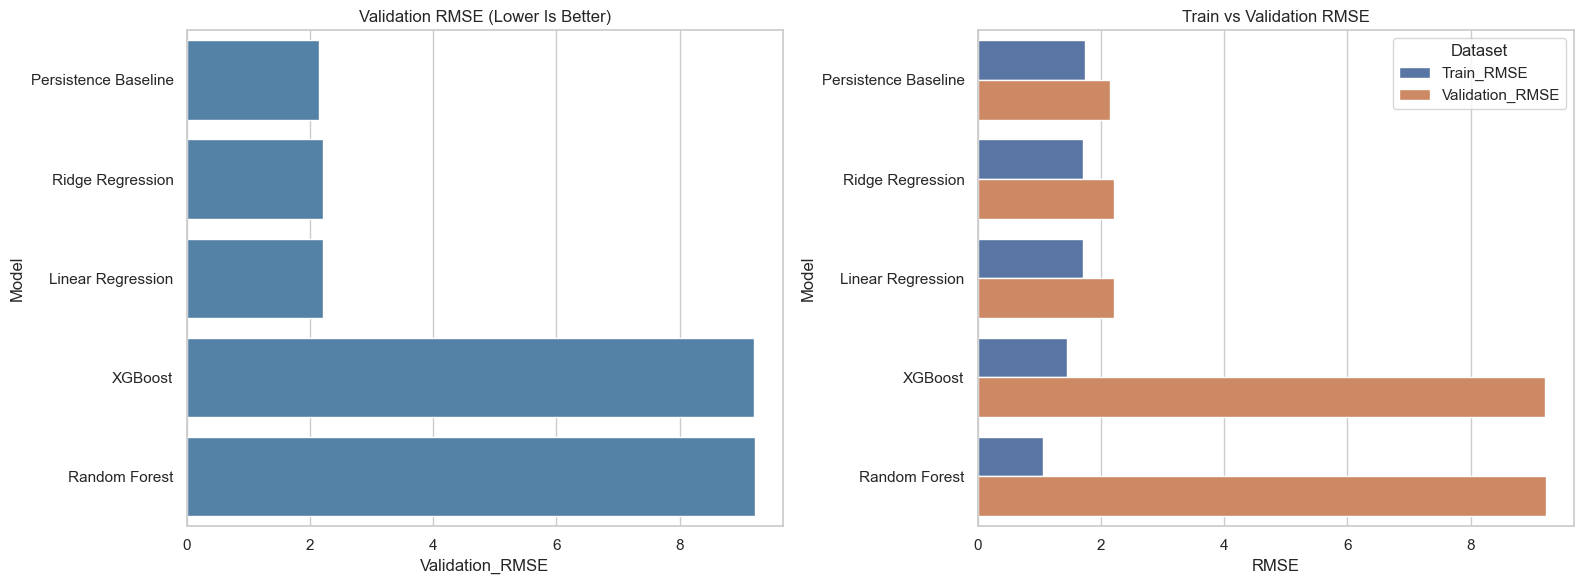

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = validation_comparison.sort_values("Validation_RMSE")["Model"]
sns.barplot(
    data=validation_comparison,
    x="Validation_RMSE",
    y="Model",
    order=order,
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Validation RMSE (Lower Is Better)")

rmse_long = validation_comparison.melt(
    id_vars="Model",
    value_vars=["Train_RMSE", "Validation_RMSE"],
    var_name="Dataset",
    value_name="RMSE",
)
sns.barplot(data=rmse_long, x="RMSE", y="Model", hue="Dataset", ax=axes[1])
axes[1].set_title("Train vs Validation RMSE")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "validation_comparison_and_overfitting.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Locked Test Evaluation


**Purpose of this section:** after model selection is fixed, retrain using Train + Validation and evaluate once on the untouched 2024 Test set.

This is important because the test set should represent unseen future data. We should not tune the model after seeing the test result.


In [7]:
# After selection is locked, use Train + Validation to fit final models.
development_df = pd.concat([train_df, validation_df], ignore_index=True)
X_development = development_df[feature_columns]
y_development = development_df[target_column]

test_rows = []
final_models = {}
test_predictions = pd.DataFrame(
    {
        "Date": test_df["Date"],
        "Current_Close": test_df["Close"],
        "Actual_Target_Close": y_test,
        "Persistence_Baseline": test_df["Close"],
    }
)

baseline_test = regression_metrics(y_test, test_df["Close"], test_df["Close"])
test_rows.append({"Model": "Persistence Baseline", **baseline_test})

for model_name, search in searches.items():
    fitted_model = clone(search.best_estimator_).fit(X_development, y_development)
    final_models[model_name] = fitted_model
    # Predict only once on the untouched 2024 test set.
    prediction = fitted_model.predict(X_test)
    test_predictions[model_name] = prediction
    test_rows.append(
        {
            "Model": model_name,
            **regression_metrics(y_test, prediction, test_df["Close"]),
        }
    )

test_comparison = pd.DataFrame(test_rows)
test_comparison["Locked_Selection"] = test_comparison["Model"].eq(locked_model_name)
test_comparison = test_comparison.sort_values("RMSE").reset_index(drop=True)

test_comparison.to_csv(RESULTS_DIR / "test_model_comparison.csv", index=False)
test_predictions.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
display(test_comparison)

selected_test_metrics = test_comparison.loc[
    test_comparison["Model"] == locked_model_name
].iloc[0]
baseline_test_metrics = test_comparison.loc[
    test_comparison["Model"] == "Persistence Baseline"
].iloc[0]

print("Locked model:", locked_model_name)
print(f"Locked-model test RMSE: {selected_test_metrics['RMSE']:.4f}")
print(f"Persistence test RMSE: {baseline_test_metrics['RMSE']:.4f}")
print("Locked model beats persistence on test:", selected_test_metrics["RMSE"] < baseline_test_metrics["RMSE"])


,Model,MAE,MSE,RMSE,R2,Directional_Accuracy,Locked_Selection
0,Persistence Baseline,2.104677,8.182982,2.860591,0.987430,0.003984,False
1,Ridge Regression,2.119608,8.273490,2.876368,0.987291,0.490040,True
2,Linear Regression,2.121202,8.292554,2.879679,0.987262,0.505976,False
3,Random Forest,19.415342,687.615188,26.222418,-0.056252,0.402390,False
4,XGBoost,19.895062,721.621764,26.863019,-0.108490,0.450199,False


Locked model: Ridge Regression
Locked-model test RMSE: 2.8764
Persistence test RMSE: 2.8606
Locked model beats persistence on test: False


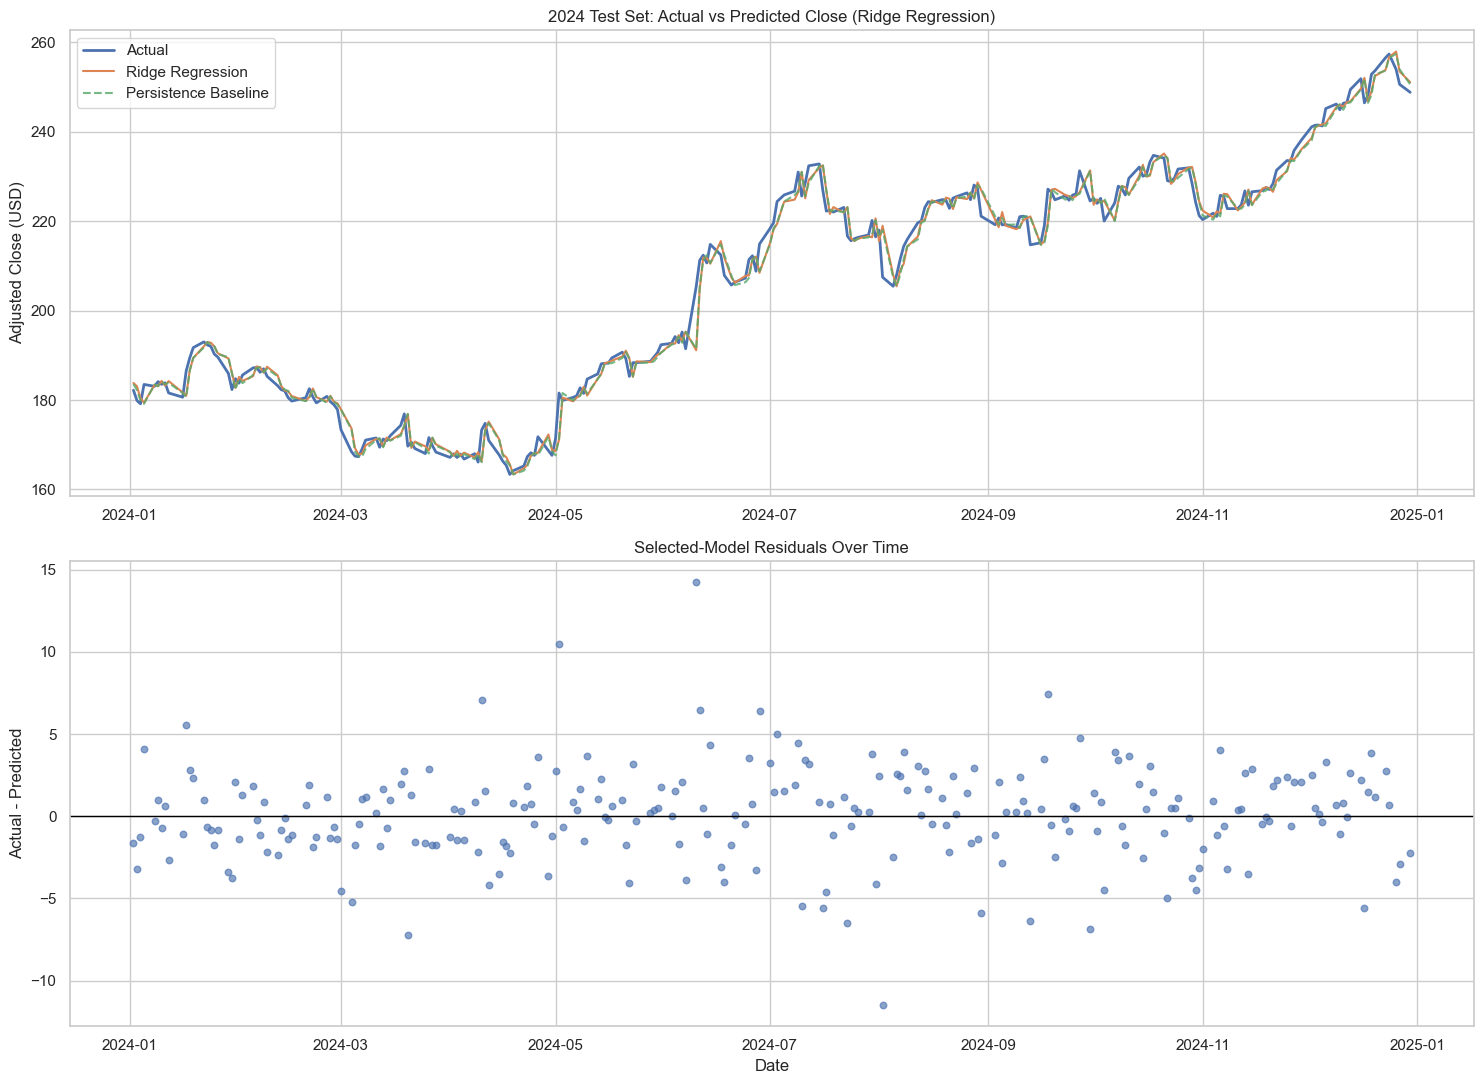

In [8]:
selected_prediction = test_predictions[locked_model_name]
selected_residuals = y_test.to_numpy() - selected_prediction.to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(15, 11))
axes[0].plot(test_df["Date"], y_test, label="Actual", linewidth=2)
axes[0].plot(test_df["Date"], selected_prediction, label=locked_model_name, linewidth=1.5)
axes[0].plot(
    test_df["Date"], test_df["Close"], label="Persistence Baseline", linestyle="--", alpha=0.8
)
axes[0].set_title(f"2024 Test Set: Actual vs Predicted Close ({locked_model_name})")
axes[0].set_ylabel("Adjusted Close (USD)")
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].scatter(test_df["Date"], selected_residuals, alpha=0.65, s=22)
axes[1].set_title("Selected-Model Residuals Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Actual - Predicted")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "selected_model_test_predictions_and_residuals.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Model-Agnostic Feature Importance


**Purpose of this section:** explain which features matter most for the selected Ridge model.

Permutation importance shuffles one feature at a time. If the model error increases a lot after shuffling a feature, that feature is important.


,Feature,Importance_Mean,Importance_Std
3,Close,24.134669,0.699399
2,Low,12.341770,0.392983
0,Open,11.007399,0.385501
5,MA7,3.235217,0.174946
1,High,3.008278,0.173505
15,Close_Lag5,0.802635,0.103116
14,Close_Lag1,0.183606,0.055335
8,Log_Return,0.152022,0.042707
7,Daily_Return,0.100688,0.040342
10,Volume_Change,0.008363,0.007702


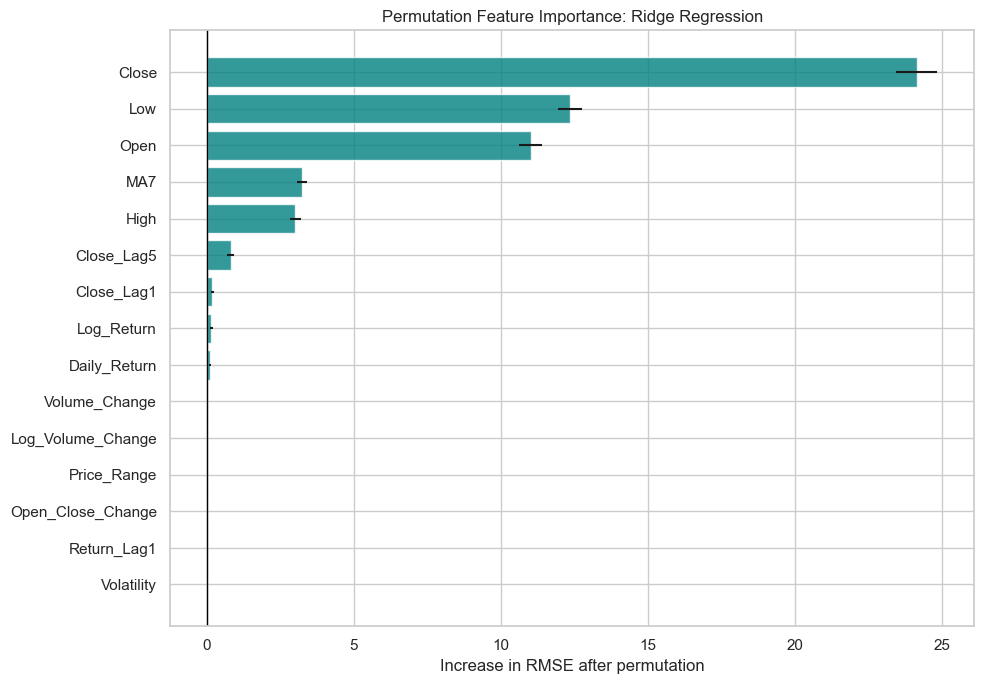

In [9]:
best_model = final_models[locked_model_name]

# Permutation importance shows how much RMSE gets worse when a feature is shuffled.
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importance_df = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Importance_Mean": importance.importances_mean,
        "Importance_Std": importance.importances_std,
    }
).sort_values("Importance_Mean", ascending=False)

importance_df.to_csv(RESULTS_DIR / "permutation_feature_importance.csv", index=False)
display(importance_df)

plot_importance = importance_df.head(15).sort_values("Importance_Mean")
plt.figure(figsize=(10, 7))
plt.barh(
    plot_importance["Feature"],
    plot_importance["Importance_Mean"],
    xerr=plot_importance["Importance_Std"],
    color="teal",
    alpha=0.8,
)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Permutation Feature Importance: {locked_model_name}")
plt.xlabel("Increase in RMSE after permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "selected_model_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Save the Reproducible Model Package and Discussion


**Purpose of this section:** save the selected model, metadata, and written discussion so the experiment can be checked or reproduced later.

The metadata records the selected model, features, split periods, final metrics, and library versions.


In [10]:
# Save final model package for reproducibility.
model_package = {
    "pipeline": best_model,
    "feature_columns": feature_columns,
    "target_column": target_column,
    "forecast_definition": "Features after close on day t predict adjusted close on day t+1",
    "locked_model_name": locked_model_name,
}
joblib.dump(model_package, MODELS_DIR / "best_aapl_next_day_model.joblib")

# Save experiment details and final metrics.
metadata = {
    "locked_model_name": locked_model_name,
    "best_parameters": searches[locked_model_name].best_params_,
    "feature_columns": feature_columns,
    "target_column": target_column,
    "random_state": RANDOM_STATE,
    "cv": {"type": "TimeSeriesSplit", "n_splits": 5, "gap": 1},
    "train_period": [str(train_df["Date"].min().date()), str(train_df["Date"].max().date())],
    "validation_period": [
        str(validation_df["Date"].min().date()),
        str(validation_df["Date"].max().date()),
    ],
    "test_period": [str(test_df["Date"].min().date()), str(test_df["Date"].max().date())],
    "test_metrics": {
        metric: float(selected_test_metrics[metric])
        for metric in ["MAE", "MSE", "RMSE", "R2", "Directional_Accuracy"]
    },
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
    },
}
(MODELS_DIR / "best_model_metadata.json").write_text(
    json.dumps(metadata, indent=2), encoding="utf-8"
)

baseline_status = (
    "outperformed"
    if selected_test_metrics["RMSE"] < baseline_test_metrics["RMSE"]
    else "did not outperform"
)
overfit_status = validation_comparison.loc[
    validation_comparison["Model"] == locked_model_name, "Potential_Overfitting"
].iloc[0]
flagged_models = validation_comparison.loc[
    validation_comparison["Potential_Overfitting"], "Model"
].tolist()
flagged_text = ", ".join(flagged_models) if flagged_models else "None"

discussion = f'''# Model Development Discussion

## Selection
The model was selected using 2023 validation RMSE before the 2024 test set was evaluated. The locked model is **{locked_model_name}**.

## Final test performance
- MAE: {selected_test_metrics['MAE']:.4f}
- MSE: {selected_test_metrics['MSE']:.4f}
- RMSE: {selected_test_metrics['RMSE']:.4f}
- R-squared: {selected_test_metrics['R2']:.4f}
- Directional Accuracy: {selected_test_metrics['Directional_Accuracy']:.2%}

The locked model {baseline_status} the persistence baseline on test RMSE. Potential overfitting flag: **{overfit_status}**.

## Overfitting and model behavior
Models flagged by a validation-to-training RMSE ratio above 1.5: **{flagged_text}**. Random Forest and XGBoost are strong nonlinear learners, but tree ensembles do not naturally extrapolate beyond the price levels observed during fitting. Their generalization gaps are therefore important evidence when the market enters a higher-price regime. The regularized Ridge model was selected because its validation performance was more stable, not because of training fit alone.

## Strengths
- Chronological evaluation mirrors real forecasting.
- Pipelines prevent preprocessing inconsistency.
- Expanding-window cross-validation and a one-row gap reduce temporal leakage.
- The untouched test set is evaluated only after model selection.

## Weaknesses
- Daily stock movements have low signal-to-noise ratio and may change across market regimes.
- Strongly correlated price features can divide permutation importance across related variables.
- High price-level R-squared can coexist with limited directional accuracy, so the persistence baseline is essential.
- Results cover one stock and one historical period and should not be treated as investment advice.

## Ethical considerations
Predictions are uncertain and may encourage financial risk if presented without limitations. The model excludes news, macroeconomic events, transaction costs, and sudden structural changes. Outputs are for academic analysis, not financial advice.
'''
(RESULTS_DIR / "model_development_discussion.md").write_text(discussion, encoding="utf-8")

print(discussion)
print("Saved model:", (MODELS_DIR / "best_aapl_next_day_model.joblib").resolve())


# Model Development Discussion

## Selection
The model was selected using 2023 validation RMSE before the 2024 test set was evaluated. The locked model is **Ridge Regression**.

## Final test performance
- MAE: 2.1196
- MSE: 8.2735
- RMSE: 2.8764
- R-squared: 0.9873
- Directional Accuracy: 49.00%

The locked model did not outperform the persistence baseline on test RMSE. Potential overfitting flag: **False**.

## Overfitting and model behavior
Models flagged by a validation-to-training RMSE ratio above 1.5: **XGBoost, Random Forest**. Random Forest and XGBoost are strong nonlinear learners, but tree ensembles do not naturally extrapolate beyond the price levels observed during fitting. Their generalization gaps are therefore important evidence when the market enters a higher-price regime. The regularized Ridge model was selected because its validation performance was more stable, not because of training fit alone.

## Strengths
- Chronological evaluation mirrors real forecasting.
- Pip

## Completion Checklist

- [x] Four regression models trained and compared
- [x] Pipelines used for every machine-learning model
- [x] Expanding-window time-series cross-validation
- [x] Hyperparameter tuning
- [x] Chronological train/validation/test split
- [x] Overfitting analysis
- [x] MAE, MSE, RMSE, R-squared, and Directional Accuracy
- [x] Persistence baseline
- [x] Feature-importance analysis
- [x] Ethical considerations and model limitations
- [x] Reproducible saved model and metadata


Final check: this notebook covers the model-development requirements, including multiple models, pipelines, cross-validation, hyperparameter tuning, overfitting check, baseline comparison, and final evaluation.
